In [1]:
import pandas as pd
import seaborn as sns
import statsmodels as st
import scipy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score 

In [26]:
thresholds={"temperature":{"Hyper- or Hypothermia":lambda x:  not(36 <= x <=  38)},
           "pH":{"pH imbalances":lambda x:  7 <= x <= 7.9},
           "sodium":{"Hypernatremia":lambda x: x>=3.6, "cystic fibrosis":lambda x: x >=2},
           "glucose":{"Hypoglycemia":lambda x: x <= 0.5}}


thresholds={"temperature":{"Hypothermia":lambda x: x<=36.5, "Hyperthermia":lambda x: x >= 37.5},
           "pH":{"pH high imbalance":lambda x: x>7.5, "pH low imbalance":lambda x: x<7},
           "sodium":{"Hypernatremia":lambda x: x>3.5, "cystic fibrosis":lambda x: x>2},
           "glucose":{"Hypoglycemia":lambda x: x<=0.5}}

TEMPERATURE
 Hypothermia 
  ACC:0.9811 F1: 0.9817, Kandell:0.843, Spearman:0.954

 Hyperthermia 
  ACC:0.9658 F1: 0.9715, Kandell:0.843, Spearman:0.954

PH
 pH above 7.5 
  ACC:0.9336 F1: 0.9577, Kandell:0.875, Spearman:0.967

 pH below 7 
  ACC:0.9299 F1: 0.9410, Kandell:0.875, Spearman:0.967

SODIUM
 Hypernatremia 
  ACC:0.9252 F1: 0.9095, Kandell:0.868, Spearman:0.965

 cystic fibrosis 
  ACC:0.9140 F1: 0.9319, Kandell:0.868, Spearman:0.965

GLUCOSE
 Hypoglycemia 
  ACC:0.9808 F1: 0.9916, Kandell:0.907, Spearman:0.982



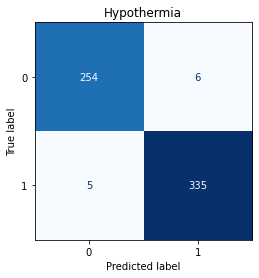

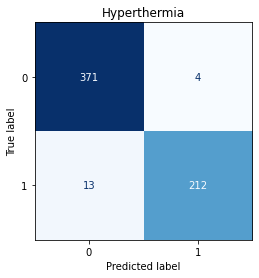

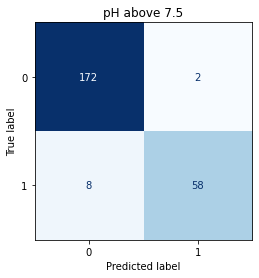

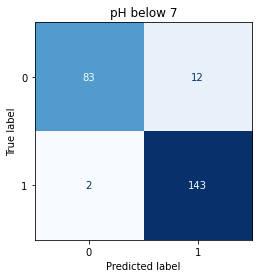

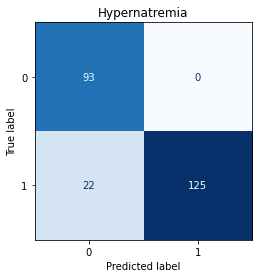

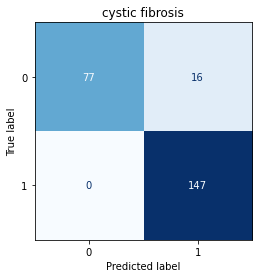

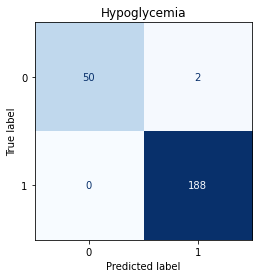

In [3]:
thresholds={"temperature":{"Hypothermia":lambda x: x<=36.5, "Hyperthermia":lambda x: x>=37.5},
            "pH":{"pH above 7.5":lambda x: x>7.5, "pH below 7":lambda x: x<6.9},
            "sodium":{"Hypernatremia":lambda x: x>3.5, "cystic fibrosis":lambda x: x>2},
            "glucose":{"Hypoglycemia":lambda x: x<=0.5}}

for value, d_opt in thresholds.items():
    df= pd.read_csv("model_unet_mlp_model_{}_noise0_2025.csv".format(value))
    print(value.upper())

    for cond, opt in d_opt.items():
        df["true_lable"] = df.target_array_real.apply(opt)
        df["pred_lable"] = df.pred_array_real.apply(opt)
        
        print(" {} \n  ACC:{:.4f} F1: {:.4f}, Kandell:{:.3f}, Spearman:{:.3f}\n".format(
                                                       cond,
                                                       balanced_accuracy_score(df["true_lable"], df["pred_lable"]),
                                                       f1_score(df["true_lable"], df["pred_lable"], average="weighted"),
                                                       sc.stats.kendalltau(df.target_array_real, df.pred_array_real).statistic, 
                                                       sc.stats.spearmanr(df.target_array_real, df.pred_array_real).statistic
                                                      ))
        

        disp=ConfusionMatrixDisplay(confusion_matrix(df["true_lable"], df["pred_lable"]))
        d = disp.plot(cmap=plt.cm.Blues, colorbar=False);
        d.ax_.set_title(cond)
        plt.savefig(cond+".pdf")


# Glucose

In [120]:
df= pd.read_csv("predictions_2025-04-07_model_GLUCOSE_clean.csv")
df.head()

,target_0_1,pred_0_1,target_array_real,pred_array_offset
0,0.323636,0.536012,0.16,0.29070
1,0.090909,0.029880,-0.00,-0.03990
2,0.149091,0.096733,0.04,0.00380
3,0.090909,0.023191,-0.00,-0.04465
4,0.207273,0.244919,0.08,0.10070


<Axes: xlabel='target_array_real', ylabel='pred_array_offset'>

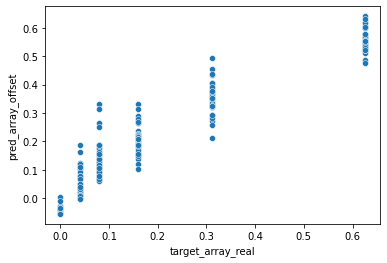

In [121]:
sns.scatterplot(x="target_array_real", y="pred_array_offset", data=df)

In [122]:
sc.stats.kendalltau(df.target_array_real, df.pred_array_offset), sc.stats.spearmanr(df.target_array_real, df.pred_array_offset)

(SignificanceResult(statistic=0.872801930314933, pvalue=1.0201667929708446e-82),
 SignificanceResult(statistic=0.9635731026105937, pvalue=1.7087404557523874e-147))

0.9954545454545455


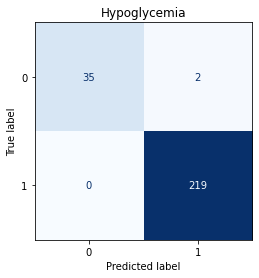

In [123]:
df["true_lable"] = df.target_array_real < 0.5 
df["pred_lable"] = df.pred_array_offset < 0.5 
print(f1_score(df["true_lable"], df["pred_lable"]))

title = "Hypoglycemia"
disp=ConfusionMatrixDisplay(confusion_matrix(df["true_lable"], df["pred_lable"]))
d = disp.plot(cmap=plt.cm.Blues, colorbar=False);
d.ax_.set_title(title)
plt.savefig(title+".pdf")